# Example run of inverse problem.

## Preparing the notebook.

### Flags for autoreloading.

In [ ]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Optionally autoreload notebook.

In [2]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

### Importing the libraries.

In [1]:
import sys
from typing import Literal, Type

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist
from scipy.special import softmax
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import torch
import yaml

from sc_exp_design.constants import DataFields, ParamsFields, PredictionFields
from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching, TargetPredictionModel, FlowMap
#from sc_exp_design.models.inverse import LossGuidedFlow
from sc_exp_design.utils import set_reproducibility
from sc_exp_design.training.callbacks import MetricsCallBack, TrainingCallBacks


### Constants.

In [2]:
BASE_DIR = "/home/icb/ilia.navosha/expDesign/collab-goettgens-SFC"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/output/checkpoints/conditional_model/2026-09-09_10-08-58/still-salad-11_FlowMatching.pkl"

PRIOR_VELOCITY_PATH = "/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/output/checkpoints/prior/flow_matching/2026-09-09_21-09-10/gallant-forest-2_FlowMatching.pkl"
PRIOR_FLOW_MAP_PATH = "/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/output/checkpoints/prior/flow_matching/2026-09-10_13-12-36/smart-bush-3_FlowMap.pkl"
TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/output/checkpoints/2026-09-01_15-33-38/deep-wood-2_TargetPredictionModel.pkl"
ANNOTATION_CONFIG_PATH = "/home/icb/ilia.navosha/expDesign/collab-goettgens-SFC/prior/config/annotation/default.yaml"

perturbation_obs_key = "condition"
cell_state_rep = "X_train_pca"

RANDOM_SEED = 42

### Importing Additional Modules.

In [10]:
sys.path.insert(0, f"{BASE_DIR}/shared_utils")
from forward_model import ForwardModel
from lambda_schedulers import LambdaScheduler, ExponentialDecayScheduler, ReciprocalDecayScheduler
from loss_guidance import LossGuidedFlow
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel


### Reading annotation config.

In [11]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

### Setting seed for reproducibility.

In [12]:
set_reproducibility(RANDOM_SEED)

### Utility function for predictions.

In [13]:
def get_prediction_adata(
    idx,
    sample,
    X_channel,
    train_adata_fwd,
    val_adata_fwd,
    perturbation_id,
    nn_val,
    perturbation_obs_key,
    cell_state_rep,
    perturbation_reps,
):
    # concatenating with predictions
    x_channel = np.concatenate(
        (
            train_adata_fwd.obsm[cell_state_rep],
            val_adata_fwd.obsm[cell_state_rep],
            X_channel,
        ), axis=0
    )

    # handling conditions
    conditions = np.concatenate(
        (
            train_adata_fwd.obsm[perturbation_id],
            val_adata_fwd.obsm[perturbation_id],
            np.repeat(sample[None], X_channel.shape[0], axis=0)
        )
    )
    unique_perts = np.unique(conditions, axis=0)
    perts_id = np.apply_along_axis(
        lambda e: np.where(
            np.all(
                unique_perts == e, axis=-1
            ))[0].item(),
        -1,
        conditions
    ).tolist()

    # retrieving the mask for current nearest neighbor
    train_cond_mask = np.all(np.isclose(train_adata_fwd.obsm[perturbation_id], nn_val, atol=1e-5, rtol=1e-3), axis=-1)

    # preparing the annotations
    obs = pd.DataFrame(
        {
            "dataset_type": [
                "in-distribution" for _ in range(len(train_adata_fwd))
            ] + [
                "ood" for _ in range(len(val_adata_fwd))
            ] + [
                "generated" for _ in range(len(X_channel))
            ],
            "is_generated": [
                False for _ in range(len(train_adata_fwd))
            ] + [
                False for _ in range(len(val_adata_fwd))
            ] + [
                True for _ in range(len(X_channel))
            ],
            "is_true_ood": [
                False for _ in range(len(train_adata_fwd))
            ] + [
                True for _ in range(len(val_adata_fwd))
            ] + [
                False for _ in range(len(X_channel))
            ],
            "is_true_nn_cond": train_cond_mask.tolist() + [
                False for _ in range(len(val_adata_fwd))
            ] + [
                False for _ in range(len(X_channel))
            ],
            perturbation_obs_key: perts_id
        }
    )
    obsm = {
        perturbation_reps: conditions,
    }
    uns = {"sampled_pert": sample, "nn_vals": nn_val}
    var = pd.DataFrame(index=train_adata_fwd.var_names)

    # creating adata
    pred_adata_group = sc.AnnData(
        X=x_channel,
        obs=obs,
        obsm=obsm,
        var=var,
        uns=uns
    )

    # computing pcs, neighbors, umap
    sc.pp.pca(pred_adata_group)
    sc.pp.neighbors(pred_adata_group)
    sc.tl.umap(pred_adata_group)
    
    # storing the results
    print(f"AnnData created for prior sample {idx} -> {pred_adata_group}")
    return pred_adata_group


def generated_density_knn(X_true, X_generated, k=20, bandwidth=None):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_true)
    distances, indices = nbrs.kneighbors(X_generated)
    
    # Auto-bandwidth: median distance of neighbors
    if bandwidth is None:
        bandwidth = np.median(distances)

    density = np.zeros(X_true.shape[0])

    # Gaussian kernel weights
    weights = np.exp(-(distances**2) / (2 * bandwidth**2))

    # Add weighted contributions
    for gen_idx in range(len(X_generated)):
        for neighbor_pos, real_idx in enumerate(indices[gen_idx]):
            density[real_idx] += weights[gen_idx, neighbor_pos]

    return density

## Loading Pre-Trained Forward Model.

### Cellular Response Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

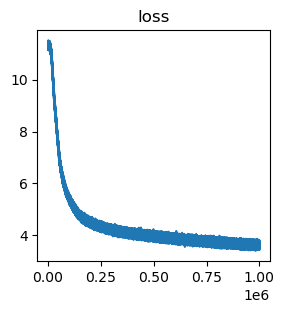

In [14]:
perturbation_response_prediction_model = FlowMatching.load(
    PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH
)
perturbation_response_prediction_model.trainer.plot_training_logs()

### Target Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

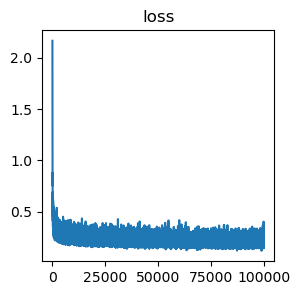

In [15]:
target_prediction_model = TargetPredictionModel.load(
    TARGET_PREDICTION_MODEL_CHECKPOINT_PATH
)
ct_le = LabelEncoder().fit(target_prediction_model.train_data.adata.obs["Region"].values)
g_model = target_prediction_model.target_prediction_model
target_prediction_model.target_predictor_trainer.plot_training_logs()

### Initializing forward model.

In [16]:
forward_model = ForwardModel(
    forward_model=perturbation_response_prediction_model,
    target_prediction_model=g_model,
    #target_prediction_model=target_prediction_model,
)

## Load Prior Flow.

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_features=16,

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

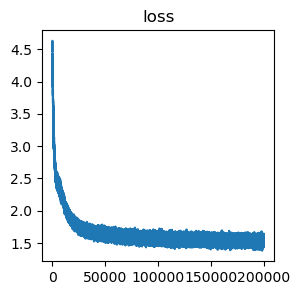

In [17]:
prior_flow = FlowMatching.load(PRIOR_VELOCITY_PATH)
print(prior_flow.velocity_field)
prior_flow.trainer.plot_training_logs()

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

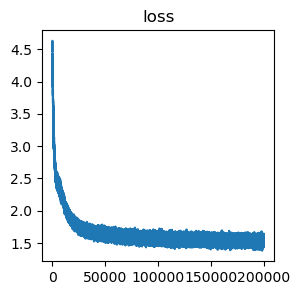

In [18]:
prior_flow_map = FlowMap.load(PRIOR_FLOW_MAP_PATH)
prior_flow.trainer.plot_training_logs()

## Prepare base adata.

### Subsampling train and validation data.

In [19]:
n_train_cells = 75_000
n_val_cells = 25_000
train_adata_fwd = sc.pp.sample(
    perturbation_response_prediction_model.train_data.adata,
    n=n_train_cells,
    copy=True
)
val_adata_fwd = next(iter(perturbation_response_prediction_model.validation_data.values())).adata
print(f"{train_adata_fwd=}, {val_adata_fwd=}")

train_adata_fwd=AnnData object with n_obs × n_vars = 75000 × 4000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'plateID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'percent_mito', 'n_counts', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_4', 'leiden_10', 'merged_clusters', 'final_clustering', 'final_clustering_reset', 'merged_clusters_from_10', 'M_XAV', 'M_CHIR', 'M_RA', 'M_FGF8', 'M_BMP4', 'M_SHH', 'M_PM', 'media', 'sample-CellID', 'Neuron_type', 'Division', 'Region', 'FGF8_conc', 'FGF8_start_time', 'FGF8_end_time', 'XAV_conc', 'XAV_start_time', 'XAV_end_time', 'RA_conc', 'RA_start_time', 'RA_end_time', 'CHIR_conc', 'CHIR_start_time', 'CHIR_end_time', '

### Predicting cell type on train and validation data.

In [20]:
X_train = train_adata_fwd.obsm[cell_state_rep]
X_val = val_adata_fwd.obsm[cell_state_rep]
g_model.eval()
with torch.no_grad():
    G_logits_train = g_model(
        torch.from_numpy(X_train).float().to("cuda")
    )["Region"].detach().cpu().numpy()
    G_logits_val = g_model(
        torch.from_numpy(X_val).float().to("cuda")
    )["Region"].detach().cpu().numpy()
G_probs_train = softmax(G_logits_train, axis=1)
G_probs_val = softmax(G_logits_val, axis=1)
G_id_train = G_probs_train.argmax(1)
G_id_val = G_probs_val.argmax(1)
G_label_train = ct_le.inverse_transform(G_id_train)
G_label_val = ct_le.inverse_transform(G_id_val)
target_probs = G_probs_val.mean(0)
print(f"{G_logits_train.shape=}, {G_logits_val.shape=}, {G_probs_train.shape=}, {G_probs_val.shape=}, {G_id_train.shape=}, {G_id_val.shape=}, {G_label_train.shape=}, {G_label_val.shape=}")

G_logits_train.shape=(75000, 8), G_logits_val.shape=(11814, 8), G_probs_train.shape=(75000, 8), G_probs_val.shape=(11814, 8), G_id_train.shape=(75000,), G_id_val.shape=(11814,), G_label_train.shape=(75000,), G_label_val.shape=(11814,)


In [21]:
classes = ct_le.classes_.tolist()
target_region = 'Hindbrain'
target_region_idx = classes.index(target_region)
target_probs = np.zeros(len(classes))
target_probs[target_region_idx] = 1.0

### Constructing base adata.

In [22]:
annotation_dict

{'protocol_columns': ['BMP4', 'CHIR', 'FGF8', 'RA', 'SHH', 'XAV']}

In [23]:
train_adata_fwd

AnnData object with n_obs × n_vars = 75000 × 4000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'plateID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'percent_mito', 'n_counts', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_4', 'leiden_10', 'merged_clusters', 'final_clustering', 'final_clustering_reset', 'merged_clusters_from_10', 'M_XAV', 'M_CHIR', 'M_RA', 'M_FGF8', 'M_BMP4', 'M_SHH', 'M_PM', 'media', 'sample-CellID', 'Neuron_type', 'Division', 'Region', 'FGF8_conc', 'FGF8_start_time', 'FGF8_end_time', 'XAV_conc', 'XAV_start_time', 'XAV_end_time', 'RA_conc', 'RA_start_time', 'RA_end_time', 'CHIR_conc', 'CHIR_start_time', 'CHIR_end_time', 'SHH_conc', 'SHH_

In [24]:
X_channel_train = X_train
X_channel_val = X_val

X_channel_joint = np.concatenate((X_channel_train, X_channel_val), axis=0)

obs = pd.DataFrame({
    "cell_type": np.concatenate((G_label_train, G_label_val), axis=0),
    "dataset_type": ["train"]*G_label_train.shape[0] + ["val"]*G_label_val.shape[0]
})
obsm = {
    "cell_type_logits": np.concatenate((G_logits_train, G_logits_val), axis=0),
    cell_state_rep: np.concatenate((X_train, X_val), axis=0),
}

adata_base = sc.AnnData(
    X=X_channel_joint,
    obs=obs,
    obsm=obsm,
)
adata_base

/ictstr01/home/icb/ilia.navosha/tools/apps/micromamba/envs/jupyter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 86814 × 50
    obs: 'cell_type', 'dataset_type'
    obsm: 'cell_type_logits', 'X_train_pca'
    layers: None

### Computing PCs and neighbors.

In [25]:
sc.pp.pca(adata_base)
sc.pp.neighbors(adata_base)
sc.tl.umap(adata_base)
adata_base

AnnData object with n_obs × n_vars = 86814 × 50
    obs: 'cell_type', 'dataset_type'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'cell_type_logits', 'X_train_pca', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None

### Computing neighbor graph.

In [26]:
k = 30_000
nbrs = NearestNeighbors(n_neighbors=k).fit(adata_base.obsm[cell_state_rep])

## Prior Predictive Checks.

### Query forward model with prior samples.

In [ ]:
# n_fwd_samples = 5_000

# # forward pass
# pred_dict = forward_model.predict(
#     {
#         DataFields.PERTURBATION_DATA: {
#             perturbation_reps: torch.from_numpy(prior_samples).float().to(perturbation_response_prediction_model.device)
#         }
#     },
#     num_samples=n_fwd_samples
# )
# X_hat = pred_dict.pop("predicted_states").detach().cpu().numpy()
# G_logits = pred_dict.pop("target_prediction_data")["cell_type"].detach().cpu().numpy()

# # splitting channel and scatter features
# X_channel = X_hat[:, :, :-n_scatter_feats]
# X_scatter = X_hat[:, :, -n_scatter_feats:]
# print(f"{X_hat.shape=}, {X_channel.shape=}, {X_scatter.shape=}")

NameError: name 'perturbation_reps' is not defined

### Retrieving NN (in subsampled data) for each prior sample.

In [ ]:
# perturbation_id = "condition_concat"
# unique_protocol_conditions = np.unique(
#     train_adata_fwd.obsm[perturbation_id], axis=0
# )
# D = cdist(prior_samples, unique_protocol_conditions)
# nn_idxs = D.argmin(1)
# nn_vals = np.empty_like(prior_samples)
# for idx in range(num_prior_samples):
#     nn_vals[idx] = unique_protocol_conditions[nn_idxs[idx]]
# print(f"{unique_protocol_conditions.shape=}, {D.shape=}, {nn_vals.shape=}")

### Visualizing NN from subsampled adata.

In [ ]:
# fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
# fig.suptitle("NN from training data for each prior samples.", size=10)
# sns.heatmap(nn_vals, annot=False, ax=ax, xticklabels=train_adata.var_names)
# ax.set_yticks([]); ax.set_yticks([])
# ax.set_ylabel("Real Samples"); ax.set_ylabel("Prior Samples")
# fig.tight_layout(); fig.show()

### Visualizing distances.

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
# fig.suptitle("L2 Distance between Real and Generated Samples.", size=10)
# sns.heatmap(D, annot=False, ax=ax)
# ax.set_xticks([]); ax.set_yticks([])
# ax.set_xlabel("Real Samples"); ax.set_ylabel("Prior Samples")
# fig.tight_layout(); fig.show()

### Retrieving prior samples with minimal NN distances.

In [ ]:
# # defining the number of prior samples for which we will
# # visualize the queries from the forward model
# num_prior_samples_to_visualize = 3

# # choosing the samples with the minimum distance to the NN 
# # in the real data and retrieving the corresponding real protocol
# D_min = D.min(1)
# min_idxs_all = np.argsort(D_min)
# min_idxs = min_idxs_all[:num_prior_samples_to_visualize]

### Plotting the UMAP of the predicted subpopulations.

In [ ]:
# # storing the results
# cond2adata = {}

# # iterating over the closest samples 
# for idx in min_idxs:
#     # slicing for current condition
#     sample = prior_samples[idx]

#     x_channel = X_channel[:, idx]
#     x_scatter = X_scatter[:, idx]
#     nn_val = nn_vals[idx]
#     cond2adata[idx] = get_prediction_adata(
#         idx,
#         sample,
#         x_channel,
#         x_scatter,
#         train_adata_fwd,
#         val_adata_fwd,
#         perturbation_id,
#         nn_val,
#         perturbation_obs_key,
#         cell_state_rep,
#         perturbation_reps,
#     )

### Visualizing the sampled protocols.

In [ ]:
# for idx in cond2adata.keys():
#     sample = prior_samples[idx][None]
#     nn_val = nn_vals[idx][None]
#     fig, ax = plt.subplots(2, 1, figsize=(20, 8), dpi=100)
#     sns.heatmap(
#         sample,
#         annot=True,
#         fmt=".2f",
#         ax=ax[0],
#         xticklabels=train_adata.var_names,
#     )
#     ax[0].set_title("Prior Sample")
#     ax[0].set_yticklabels([])

#     sns.heatmap(
#         nn_val,
#         annot=True,
#         fmt=".2f",
#         ax=ax[1],
#         xticklabels=train_adata.var_names,
#     )
#     ax[1].set_title("Nearest Neighbor")
#     ax[1].set_yticklabels([])
#     fig.tight_layout()
#     fig.show()

### Plotting the cells and highlighting generated ones.

In [ ]:
# base_size = 30
# highlight_size = 180
# base_alpha=1.0
# highlight_alpha=1.0
# for idx, adata in cond2adata.items():
#     sc.pl.embedding(adata, "umap", color=["is_generated", "is_true_nn_cond"])


## Inverse Model.

### Initializing guided flow.

In [29]:
N_FORWARD_PASS_PER_SAMPLE = 350
REGULARIZATION = None
REG_STRENGTH = 1e-2
loss_fns = {"Region":lambda pred, target:-torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)}
guided_flow = LossGuidedFlow(
    prior_flow,
    forward_model,
    loss_fns,
    prior_flow_map=prior_flow_map,
    fix_noise=True,
    num_forward_pass_per_sample=N_FORWARD_PASS_PER_SAMPLE,
    regularization=REGULARIZATION,
    reg_strength=REG_STRENGTH,
    target_id="Region",
)
guided_flow.prior_vf = prior_flow.velocity_field
non_linearity = torch.nn.ReLU()
#non_linearity = torch.nn.Identity()

### Initializing lambda scheduler.

In [30]:

class ReciprocalDecayScheduler(LambdaScheduler):
    def __init__(
        self,
        lmax: float = 1.0,
        gamma: float = 1.0
    ):
        if gamma <= 0.0: raise ValueError
        self.lmax = lmax
        self.gamma = gamma

    def compute_lambda_t(self, t, *args, **kwargs):
        return torch.clamp(
            (1 - t)/t, min=0.0, max=self.lmax
        ) / self.gamma 


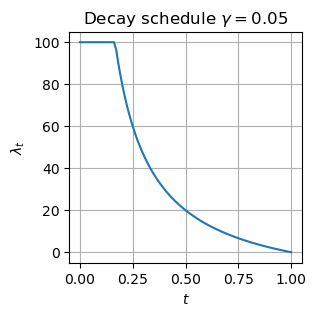

In [31]:
LMAX = 5.0
LMIN = 1.0
GAMMA = 0.05

lambda_scheduler = ExponentialDecayScheduler(LMIN, LMAX, GAMMA)
lambda_scheduler = ReciprocalDecayScheduler(LMAX, gamma=GAMMA)

# visualizing decaying scheduler
t = torch.linspace(0.0, 1.0, 100)
lambda_t = lambda_scheduler.compute_lambda_t(t)
plt.figure(figsize=(3, 3))
plt.plot(t, lambda_t)
plt.title(fr"Decay schedule $\gamma=${GAMMA}")
plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_t$")
plt.grid(True)



### Preparing configurations for posterior sampling.

In [32]:
SDE_SAMPLING = False
N_POSTERIOR_SAMPLES = 50
N_TIME_STEPS_POSTERIOR_MODEL = 30 if SDE_SAMPLING else 100
SOLVER_KWARGS_POSTERIOR_MODEL = {"method": "euler"}
seed = 42
set_reproducibility(seed)

### Sampling from posterior.

In [33]:
traj, loss_history, lambda_history, noise = guided_flow.sample_posterior(
    N_POSTERIOR_SAMPLES,
    optimal_condition={
        "Region":torch.from_numpy(target_probs).unsqueeze(0).to(guided_flow.prior_flow.device)
    },
     num_time_steps=N_TIME_STEPS_POSTERIOR_MODEL,
     solver_kwargs=SOLVER_KWARGS_POSTERIOR_MODEL,
     lambda_scheduler=lambda_scheduler,
     non_linearity=non_linearity,
     sde_sampling=SDE_SAMPLING,
)
if noise is not None:
    print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}, {noise.shape=}")
else:
    print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}")

/ictstr01/home/icb/ilia.navosha/tools/apps/micromamba/envs/jupyter/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


traj.shape=(50, 100, 6), loss_history.shape=(50, 99), lambda_history.shape=(50, 99), noise.shape=torch.Size([50, 350, 50])


### Plotting Loss History.

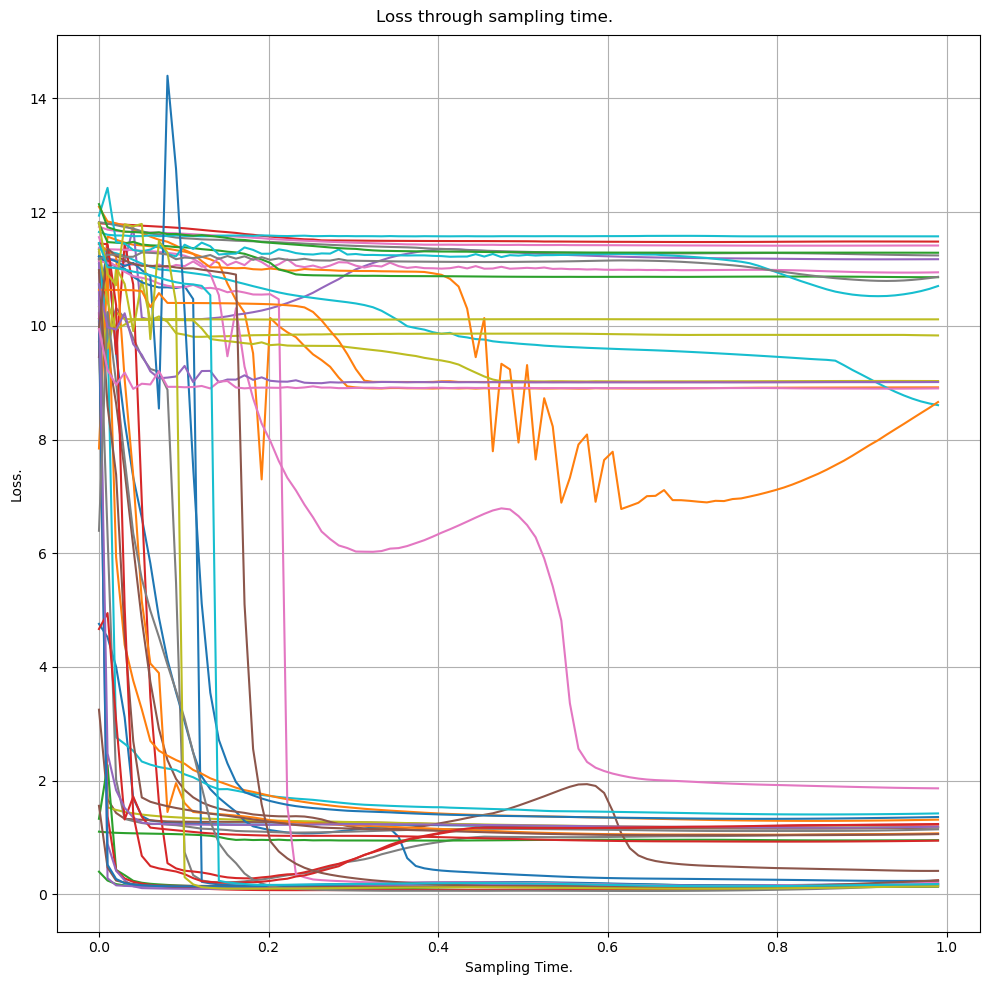

In [34]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
t = np.arange(0, 1, 1/loss_history.shape[1])
lines = ax.plot(t, loss_history.T)
fig.suptitle("Loss through sampling time.")
ax.set_xlabel("Sampling Time.")
ax.set_ylabel("Loss.")
ax.grid(1)
fig.tight_layout(); fig.show()

### Comparing with ood protocol.

Text(0.5, 1.0, 'Samples')

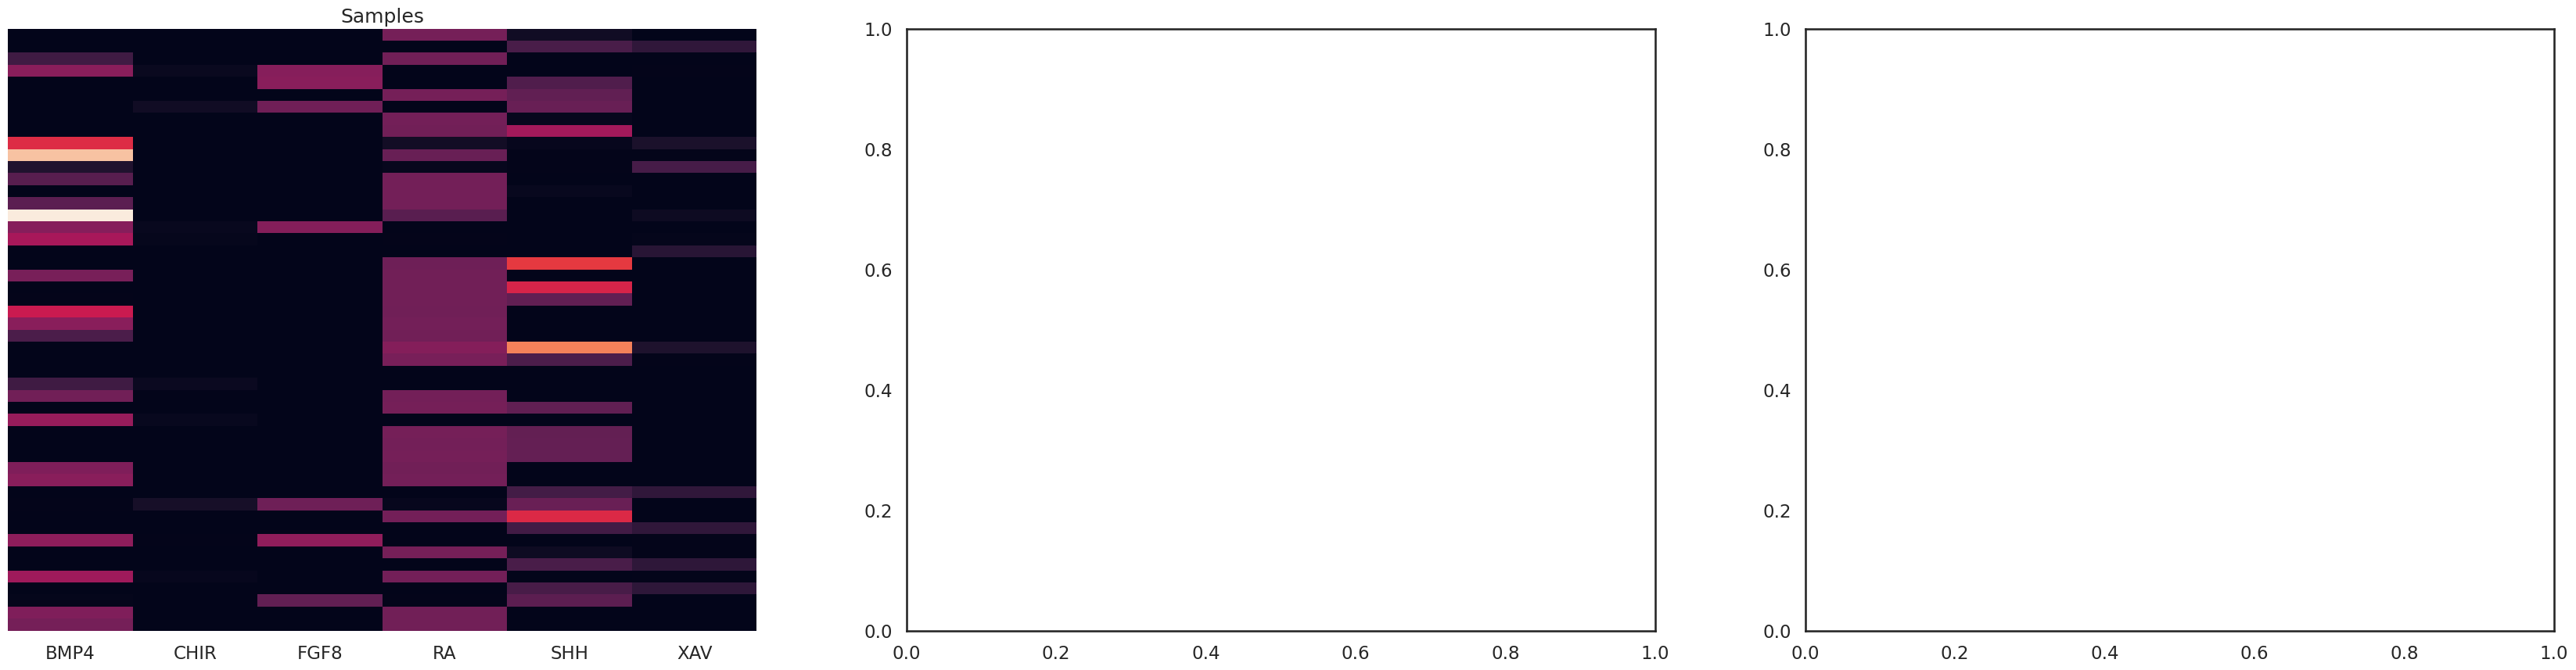

In [35]:
sns.set_style("white")
sns.set_context("talk")  # poster-friendly font sizes

#estar = np.unique(val_adata_fwd.obsm[perturbation_id], axis=0)

samples = np.maximum(traj[:, -1, :], 0)
emin_loss_idx = np.argmin(loss_history[:, -1])
min_samples = samples[emin_loss_idx][None]

fig, ax = plt.subplots(1, 3, figsize=(42, 10))  # slightly bigger for poster

#xticks = train_adata.var_names
xticks = ("BMP4", "CHIR", "FGF8", "RA", "SHH", "XAV")

# # Plot 1: samples (no annotations)
sns.heatmap(
     samples,
     annot=False,
     cbar=False,
     xticklabels=xticks,
     yticklabels=False,
     ax=ax[0]
 ); ax[0].set_title("Samples")

# # Plot 2: target (with annotations)
# sns.heatmap(
#     estar,
#     annot=True,
#     fmt=".2f",
#     cbar=False,
#     xticklabels=xticks,
#     yticklabels=False,
#     ax=ax[1]
# ); ax[1].set_title("Target")

# # Plot 2: target (with annotations)
# sns.heatmap(
#     min_samples,
#     annot=True,
#     fmt=".2f",
#     cbar=False,
#     xticklabels=xticks,
#     yticklabels=False,
#     ax=ax[2]
# ); ax[2].set_title("Best Sample")

# # Format x-axis labels
# for a in ax:
#     a.tick_params(axis='x', labelsize=16)
#     a.set_xticklabels(a.get_xticklabels(), rotation=90, ha="right")

# fig.tight_layout(pad=2)
# plt.show()

In [36]:
x_star = train_adata_fwd.uns['conditions']['RA_4+BMP4_1']

In [37]:
from scipy.spatial.distance import cdist
D = cdist(samples, x_star[None])
x_star = train_adata_fwd.uns['conditions']['RA_4+BMP4_1']
min_idx = D.argmin(0)
nn_cond = samples[min_idx]
nn_cond

array([[2.6896687 , 0.        , 0.        , 4.7470074 , 0.        ,
        0.04824838]], dtype=float32)

### Querting forward model.

In [38]:
samples.shape

(50, 6)

In [39]:
num_time_steps = 500
solver_kwargs = {"method": "euler"}
ccondition_data = torch.from_numpy(samples).float().to(perturbation_response_prediction_model.device)
ccondition_dict = {
     'repr_condition_conditions': ccondition_data.unsqueeze(1).repeat(1, N_FORWARD_PASS_PER_SAMPLE, 1),
}
cforward_out = forward_model.predict(
     {
         DataFields.SOURCE_STATE: noise,
         DataFields.PERTURBATION_DATA: ccondition_dict
     },
     return_trajectory=False,
     no_grad=True,
     num_time_steps=num_time_steps,
     solver_kwargs=solver_kwargs,
     fix_noise=True,
 )
X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
# X_channel_gen = X_gen[:, :, :-n_scatter_feats]
# X_scatter_gen = X_gen[:, :, -n_scatter_feats:]
gen_region_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["Region"].detach().cpu().numpy()
gen_region_probs = softmax(gen_region_logits, axis=-1)
#print(f"{samples.shape=} {X_gen.shape=} {gen_region_probs.shape=}, {X_channel_gen.shape=}, {X_scatter_gen.shape=}")


### Displaying induced phenotype.

0.8896931
[3.740591   0.         0.0597286  4.8130765  0.         0.05130993]
[1.79175947 0.         0.         6.90875478 0.         0.        ]


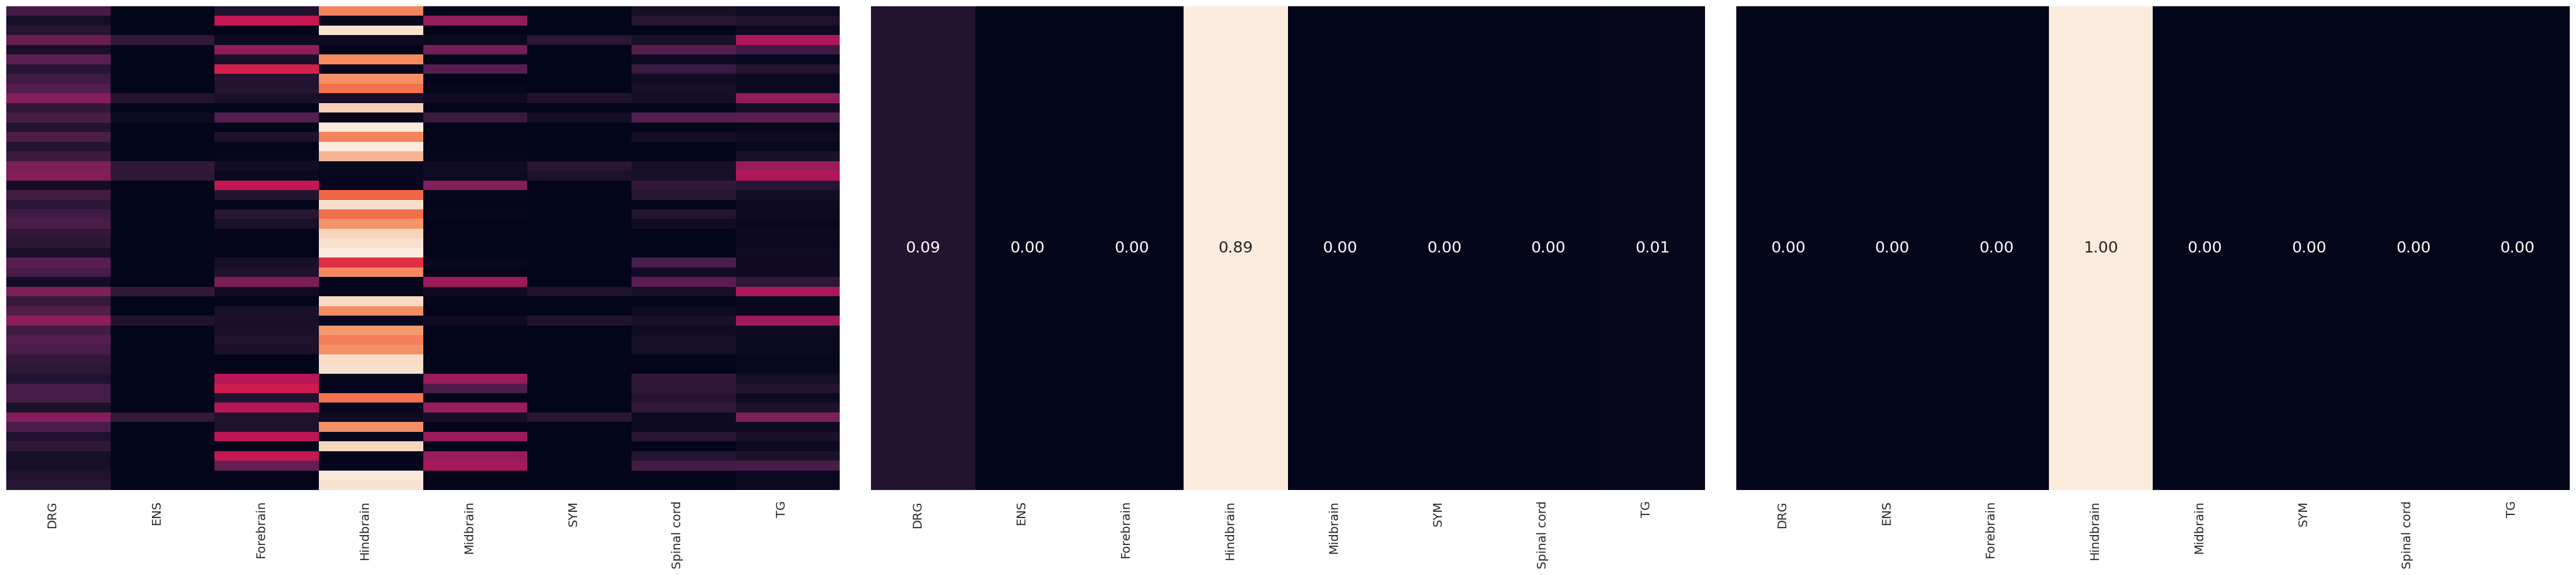

In [41]:
emin_loss_idx = np.argmin(loss_history[:, -1])
phenotype = gen_region_probs.mean(1)
best_pheno = gen_region_probs[emin_loss_idx]
best_sample = samples[emin_loss_idx]

best_prop = best_pheno.mean(0)[target_region_idx]
print(best_prop)
print(best_sample)
print(x_star)

fig, ax = plt.subplots(1, 3, figsize=(42, 10))  # bigger for poster

#xticks = [le_ct.inverse_transform(np.array([i])).item() for i in range(best_pheno.shape[-1])]
xticks = [ct_le.inverse_transform(np.array([i])).item() for i in range(best_pheno.shape[-1])]

heatmap_kwargs = dict(
     annot=False,
     cbar=False,
     xticklabels=xticks,
     yticklabels=False,
)

sns.heatmap(phenotype, ax=ax[0], **heatmap_kwargs)
sns.heatmap(best_pheno, ax=ax[1], **heatmap_kwargs)

heatmap_kwargs["annot"] = True
sns.heatmap(best_pheno.mean(0)[None], ax=ax[1], fmt=".2f", **heatmap_kwargs)
sns.heatmap(target_probs[None], ax=ax[2], fmt=".2f", **heatmap_kwargs)

# rotate x labels for readability
for a in ax:
    a.tick_params(axis='x', labelsize=14)  # larger font
    a.set_xticklabels(a.get_xticklabels(), rotation=90, ha="right")

fig.tight_layout(pad=2)
plt.show()

### Constructing adata.

In [ ]:
# emin_loss_idx = np.argmin(loss_history[:, -1])

# X_channel_gen_emin = X_channel_gen[emin_loss_idx]
# X_scatter_gen_emin = X_scatter_gen[emin_loss_idx]
# gen_region_probs = gen_region_probs[emin_loss_idx]

# X_train = train_adata_fwd.obsm[cell_state_rep]
# X_val = val_adata_fwd.obsm[cell_state_rep]

# X_channel_train = X_train[:, :-n_scatter_feats]
# X_scatter_train = X_train[:, -n_scatter_feats:]

# X_channel_val = X_val[:, :-n_scatter_feats]
# X_scatter_val = X_val[:, -n_scatter_feats:]

# with torch.no_grad():
#     train_region_probs = g_model(torch.from_numpy(X_train).float().to("cuda"))["cell_type"].detach().cpu().numpy()
#     val_region_probs = g_model(torch.from_numpy(X_val).float().to("cuda"))["cell_type"].detach().cpu().numpy()

# X_channel = np.concatenate((X_channel_train, X_channel_val, X_channel_gen_emin), axis=0)
# X_scatter = np.concatenate((X_scatter_train, X_scatter_val, X_scatter_gen_emin), axis=0)
# # Y = np.concatenate((train_region_probs, val_region_probs, gen_region_probs), axis=0)
# obs={
#     "dataset_type": ["train" for _ in range(X_train.shape[0])] + \
#         ["ood" for _ in range(X_channel_val.shape[0])] + \
#             ["generated" for _ in range(N_FORWARD_PASS_PER_SAMPLE)],
# }
# obsm = {
#     "X_channel": X_channel,
#     "X_scatter": X_scatter,
# }

# adata_gen = sc.AnnData(
#     X_channel,
#     obsm=obsm,
#     obs=obs
# )
# adata_gen.obs["is_generated"] = adata_gen.obs["dataset_type"] == "generated"

# sc.pp.pca(adata_gen)
# sc.pp.neighbors(adata_gen)
# sc.tl.umap(adata_gen)

### Visualizing cell states.

In [ ]:
# # defining figure
# fig, ax = plt.subplots(1, 3, figsize=(15, 5))
# X_umap = adata_gen.obsm["X_umap"]

# for idx, unique_val in enumerate(adata_gen.obs["dataset_type"].unique()):
#     mask =  adata_gen.obs["dataset_type"] == unique_val
#     cax = ax[idx]
#     # plotting base coords
#     cax.set_title(f"{idx}:{unique_val}")
#     cax.scatter(
#         X_umap[:, 0],
#         X_umap[:, 1],
#         c='lightgrey',  # background cells
#         s=20,           # smaller size
#         alpha=0.5
#     )
#     cax.scatter(
#         X_umap[mask, 0],
#         X_umap[mask, 1],
#         alpha=0.5,
#         s=80,
#         edgecolor='k',
#     )

## Querying pure populations.

### Calling the inverse model for each cell type.

In [43]:
results_dict = {}
for idx, ct in enumerate(ct_le.classes_):
    if ct != "Hindbrain":
        continue
    print(ct)
    g_star = np.zeros_like(target_probs)
    g_star[idx] = 1.0
    traj, loss_history, lambda_history, noise = guided_flow.sample_posterior(
        N_POSTERIOR_SAMPLES,
        optimal_condition={
            "Region":torch.from_numpy(g_star).unsqueeze(0).to(guided_flow.prior_flow.device)
        },
        num_time_steps=N_TIME_STEPS_POSTERIOR_MODEL,
        solver_kwargs=SOLVER_KWARGS_POSTERIOR_MODEL,
        lambda_scheduler=lambda_scheduler,
        non_linearity=non_linearity,
        sde_sampling=SDE_SAMPLING
    )
    results_dict[ct] = {
        "traj": traj,
        "loss_history": loss_history,
        "lambda_history": lambda_history,
        "noise": noise
    }


Hindbrain


/ictstr01/home/icb/ilia.navosha/tools/apps/micromamba/envs/jupyter/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


### Saving results dict.

In [ ]:
with open("../posterior_results.pkl", "wb") as fb:
    cloudpickle.dump(results_dict, fb)

### Loading results dict.

In [ ]:
with open("../posterior_results.pkl", "rb") as fb:
    results_dict = cloudpickle.load(fb)

### Plotting the losses for each queried cell type.

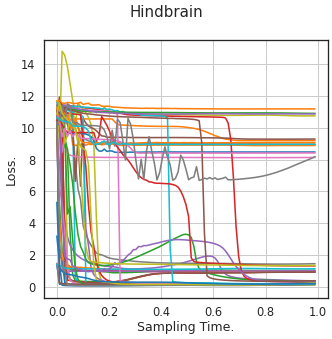

In [45]:
for ct, res_dict in results_dict.items():
    loss_history = res_dict["loss_history"]
    fig, ax = plt.subplots(figsize=(7, 7), dpi=50)
    t = np.arange(0, 1, 1/loss_history.shape[1])
    lines = ax.plot(t, loss_history.T)
    fig.suptitle(f"{ct}")
    ax.set_xlabel("Sampling Time.")
    ax.set_ylabel("Loss.")
    ax.grid(1)
    fig.tight_layout(); fig.show()
    safe_ct = ct.replace("/", "_")
    #fig.savefig(f"../plots/losses_{safe_ct}.png")

### Querying forward model.

In [47]:
N_FORWARD_PASS_PER_SAMPLE = 500
num_time_steps = 500
solver_kwargs = {"method": "euler"}

ct_preds = {}
for ct, res_dict in results_dict.items():
    # query forward model
    print(ct)
    traj = res_dict["traj"]
    noise = res_dict["noise"]
    samples = np.maximum(traj[:, -1, :], 0)
    ccondition_data = torch.from_numpy(samples).float().to(perturbation_response_prediction_model.device)
    ccondition_dict = {
        'repr_condition_conditions': ccondition_data.unsqueeze(1).repeat(1, N_FORWARD_PASS_PER_SAMPLE, 1),
    }
    batch_dict = {
        DataFields.PERTURBATION_DATA: ccondition_dict,
        DataFields.SOURCE_STATE: noise
    }
    cforward_out = forward_model.predict(
        batch_dict,
        return_trajectory=False,
        no_grad=True,
        # num_samples=n_samples,
        num_time_steps=num_time_steps,
        solver_kwargs=solver_kwargs,
        fix_noise=True,
    )
    X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
    gen_ct_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["cell_type"].detach().cpu().numpy()
    gen_ct_probs = softmax(gen_ct_logits, axis=-1)
    gen_ct_id_label = gen_ct_probs.argmax(-1)
    gen_ct_label = ct_le.inverse_transform(gen_ct_id_label.reshape(-1)).\
        reshape(gen_ct_id_label.shape[0], gen_ct_id_label.shape[1])
    print(f"{X_gen.shape=}, {gen_ct_logits.shape=} {gen_ct_id_label.shape=}, {gen_ct_label.shape=}")
    ct_preds[ct] = {
        "X": X_gen,
        "ct_logits": gen_ct_logits,
        "ct_probs": gen_ct_probs,
        "ct_label": gen_ct_label,
    }
# with open("../posterior_fwd_queries.pkl", "wb") as fb:
#     cloudpickle.dump(ct_preds, fb)


Hindbrain


AssertionError: condition_covariate='repr_condition_conditions' -> condition_data.shape=torch.Size([50, 500, 6]) | torch.Size([50, 350, 50])

### Displaying samples.

In [48]:
for ct, preds_dict in ct_preds.items():
    loss_history = results_dict[ct]["loss_history"]
    emin_loss_idx = np.argmin(loss_history[:, -1])
    ct_probs = preds_dict["ct_probs"].mean(1)
    traj = res_dict["traj"]
    samples = np.maximum(traj[:, -1, :], 0)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    fig.suptitle(ct)
    sns.heatmap(samples, annot=False, ax=ax[0], xticklabels=annotation_dict["protocol_columns"])
    sns.heatmap(samples[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=annotation_dict["protocol_columns"], fmt=".2f", annot_kws={"size": 6})
    safe_ct = ct.replace("/", "_")
    #fig.savefig(f"../plots/samples_{safe_ct}.png")

### Displaying induced phenotypes.

In [49]:
for ct, preds_dict in ct_preds.items():
    loss_history = results_dict[ct]["loss_history"]
    emin_loss_idx = np.argmin(loss_history[:, -1])
    ct_probs = preds_dict["ct_probs"].mean(1)
    traj = res_dict["traj"]
    samples = np.maximum(traj[:, -1, :], 0)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    fig.suptitle(ct)
    sns.heatmap(ct_probs, annot=False, ax=ax[0], xticklabels=ct_le.classes_)
    sns.heatmap(ct_probs[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=ct_le.classes_, fmt=".2f", annot_kws={"size": 6})
    safe_ct = ct.replace("/", "_")
    #fig.savefig(f"../plots/induced_pheno_{safe_ct}.png")

### Creating concatenated data.

In [ ]:
adatas_dict = {}
for ct, preds_dict in ct_preds.items():
    print(ct)
    loss_history = results_dict[ct]["loss_history"]
    emin_loss_idx = np.argmin(loss_history[:, -1])
    X = np.concatenate((preds_dict["X"][emin_loss_idx],
        train_adata_fwd.obsm[cell_state_rep],
        val_adata_fwd.obsm[cell_state_rep]), axis=0)
    g_model.eval()
    with torch.no_grad():
        g_logits = g_model(torch.from_numpy(X).cuda())["cell_type"].detach().cpu().numpy()
    g_probs = softmax(g_logits, axis=-1)
    g_label = ct_le.inverse_transform(g_probs.argmax(1))
    X_channel = X[:, :-n_scatter_feats]
    X_scatter = X[:, -n_scatter_feats:]
    ct_adata = sc.AnnData(
        X=X_channel,
        obsm={"X_scatter": X_scatter},
        obs={
            "Region": g_label,
            "data_type": ["gen"]*preds_dict["X"][emin_loss_idx].shape[0] + \
                ["train"]*len(train_adata_fwd) + ["val"]*len(val_adata_fwd)
        },
        var=pd.DataFrame(index=train_adata_fwd.var_names)
    )
    sc.pp.pca(ct_adata)
    sc.pp.neighbors(ct_adata)
    sc.tl.umap(ct_adata)
    adatas_dict[ct] = ct_adata


### Plotting UMAP with concatenated anndata.

In [ ]:
for ct, ct_adata in adatas_dict.items():
    X_umap = ct_adata.obsm["X_umap"]
    ct_mask = (ct_adata.obs["cell_type"] == ct) & (ct_adata.obs["data_type"] != "gen")
    gen_mask = ct_adata.obs["data_type"] == "gen"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    fig.suptitle(ct)
    axes[0].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
        # alpha=0.2
    )
    axes[0].scatter(
        X_umap[ct_mask, 0],
        X_umap[ct_mask, 1],
        s=40,
        # alpha=0.9
    )
    axes[0].set_title(f"Is Target")
    axes[0].grid(1)

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
        # alpha=0.2
    )
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
        # alpha=0.9
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(1)

    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.tight_layout()
    plt.show()
    safe_ct = ct.replace("/", "_")
    fig.savefig(f"../plots/cell_states_umap_{safe_ct}.png")

### Plotting marginals.

### Dot plot expression for each cell type for generated cells.

In [ ]:
X_list = []
ct_list = []
for ct, preds_dict in ct_preds.items():
    loss_history = results_dict[ct]["loss_history"]
    emin_loss_idx = np.argmin(loss_history[:, -1])
    X = preds_dict["X"][emin_loss_idx]
    X_list.append(X)
    ct_list.extend([ct]*X.shape[0])
X = np.concatenate(X_list, axis=0)
X = izn(torch.from_numpy(X).cuda()).detach().cpu().numpy()
adata_preds = sc.AnnData(
    X=X[:, :-n_scatter_feats],
    obs={"cell_type": ct_list},
    var=pd.DataFrame(index=train_adata_fwd.var_names)
)
sc.pl.dotplot(adata_preds, adata_preds.var_names, "cell_type")
adata_preds

### Dot plot expression for each marker per cell type real data.

In [ ]:
izn_g = IZNorm(params_fwd)
X = np.concatenate(
    (
        target_prediction_model.train_data.adata.obsm[cell_state_rep],
        target_prediction_model.validation_data.adata.obsm[cell_state_rep],
    ), axis=0
)
X = izn_g(torch.from_numpy(X).cuda()).detach().cpu().numpy()
adata_gt = sc.AnnData(
    X=X[:, :-n_scatter_feats],
    obs={"cell_type": target_prediction_model.train_data.adata.obs["cell_type"].tolist() +\
        target_prediction_model.validation_data.adata.obs["cell_type"].tolist()},
    var=pd.DataFrame(index=train_adata_fwd.var_names)
)
sc.pl.dotplot(adata_gt, adata_gt.var_names, "cell_type")
adata_gt